# Formula 1 Race Winner Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_fscore_support

# Ensure output directory exists
os.makedirs('out/images', exist_ok=True)

## 1. Load the Data
We load all the CSV files from the `data` directory.

In [2]:
circuits = pd.read_csv('data/circuits.csv')
constructor_results = pd.read_csv('data/constructor_results.csv')
constructor_standings = pd.read_csv('data/constructor_standings.csv')
constructors = pd.read_csv('data/constructors.csv')
driver_standings = pd.read_csv('data/driver_standings.csv')
drivers = pd.read_csv('data/drivers.csv')
lap_times = pd.read_csv('data/lap_times.csv')
pit_stops = pd.read_csv('data/pit_stops.csv')
qualifying = pd.read_csv('data/qualifying.csv')
races = pd.read_csv('data/races.csv')
results = pd.read_csv('data/results.csv')
seasons = pd.read_csv('data/seasons.csv')
sprint_results = pd.read_csv('data/sprint_results.csv')
status = pd.read_csv('data/status.csv')

# Merge into a single dataframe
df = results.merge(races[['raceId', 'year', 'round', 'circuitId', 'date']], on='raceId')
df = df.merge(drivers[['driverId', 'driverRef', 'nationality', 'dob']], on='driverId')
df = df.merge(constructors[['constructorId', 'constructorRef', 'nationality']], on='constructorId', suffixes=('_driver', '_constructor'))
df = df.merge(circuits[['circuitId', 'circuitRef', 'country', 'lat', 'lng']], on='circuitId')
df = df.merge(status[['statusId', 'status']], on='statusId', how='left')

print(f"Main Dataframe Shape: {df.shape}")

Main Dataframe Shape: (26759, 32)


## 2. Data Preprocessing
- Handle missing values (replace mapped `\N` with NaN)
- Convert data types (dates, numerics)

In [3]:
# Replace '\N' with NaN
df.replace('\\N', np.nan, inplace=True)

# Convert date columns
df['date'] = pd.to_datetime(df['date'])
df['dob'] = pd.to_datetime(df['dob'])

# Convert numeric columns that might be strings
numeric_cols = ['grid', 'positionOrder', 'points', 'laps']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill NaNs if appropriate (e.g. 0 points)
df['points'].fillna(0, inplace=True)

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 26759 entries, 0 to 26758
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   resultId                 26759 non-null  int64         
 1   raceId                   26759 non-null  int64         
 2   driverId                 26759 non-null  int64         
 3   constructorId            26759 non-null  int64         
 4   number                   26753 non-null  str           
 5   grid                     26759 non-null  int64         
 6   position                 15806 non-null  str           
 7   positionText             26759 non-null  str           
 8   positionOrder            26759 non-null  int64         
 9   points                   26759 non-null  float64       
 10  laps                     26759 non-null  int64         
 11  time                     7680 non-null   str           
 12  milliseconds             7680 non-null   st

C:\Users\isula\AppData\Local\Temp\ipykernel_27256\2784997595.py:14: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['points'].fillna(0, inplace=True)


## 3. Exploratory Data Analysis (EDA)
Visualizing the data and saving plots to `out/images`.

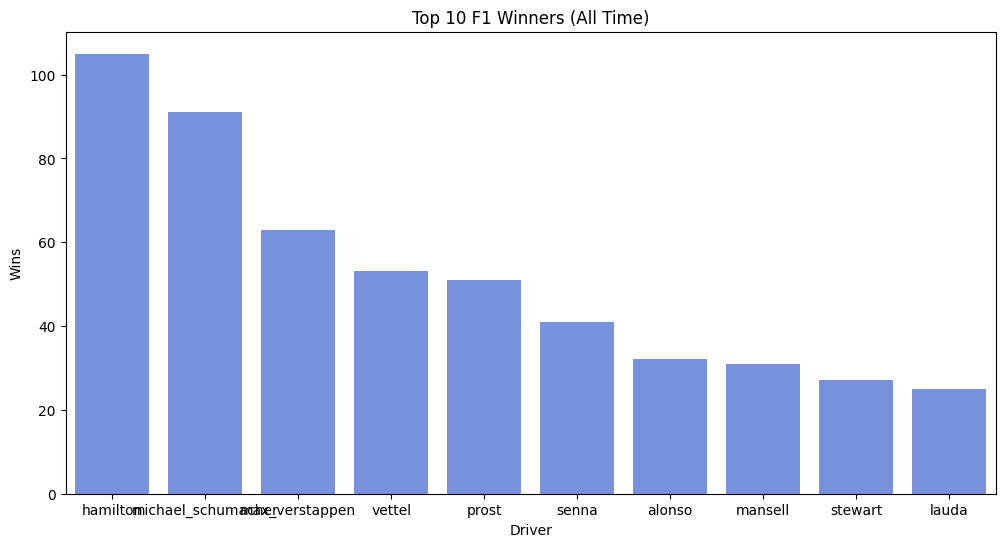

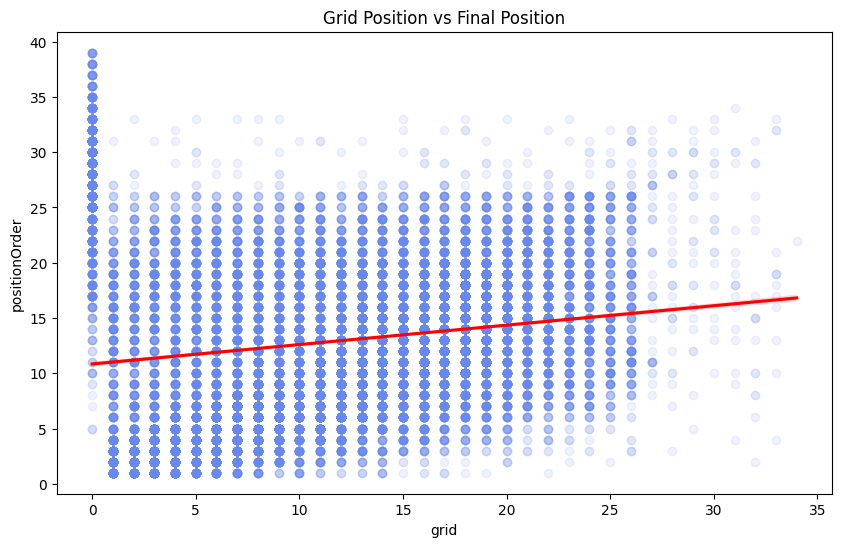

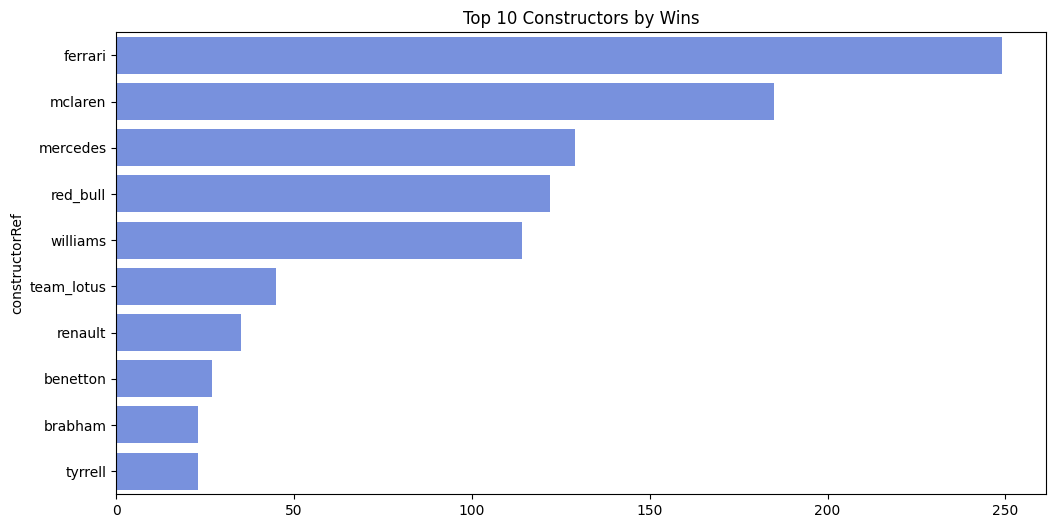

In [4]:
sns.set_palette("coolwarm")

# 1. Top 10 Winners
plt.figure(figsize=(12, 6))
top_winners = df[df['positionOrder'] == 1]['driverRef'].value_counts().head(10)
sns.barplot(x=top_winners.index, y=top_winners.values)
plt.title('Top 10 F1 Winners (All Time)')
plt.ylabel('Wins')
plt.xlabel('Driver')
plt.savefig('out/images/top_winners.png')
plt.show()

# 2. Grid Position vs Final Position Correlation
plt.figure(figsize=(10, 6))
correlation_data = df[['grid', 'positionOrder']].dropna()
sns.regplot(x='grid', y='positionOrder', data=correlation_data, scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
plt.title('Grid Position vs Final Position')
plt.savefig('out/images/grid_pos_correlation.png')
plt.show()

# 3. Constructor Wins
plt.figure(figsize=(12, 6))
top_constructors = df[df['positionOrder'] == 1]['constructorRef'].value_counts().head(10)
sns.barplot(x=top_constructors.values, y=top_constructors.index, orient='h')
plt.title('Top 10 Constructors by Wins')
plt.savefig('out/images/constructor_wins.png')
plt.show()

## 4. Feature Engineering
Creating features for the model.
- `Driver Age`: Age of driver at race date
- `Target`: 1 if winner (`positionOrder` == 1), else 0

In [5]:
# Calculate Driver Age
df['driver_age'] = (df['date'] - df['dob']).dt.days / 365.25

# Create Target Variable
df['is_winner'] = df['positionOrder'].apply(lambda x: 1 if x == 1 else 0)

# Encode Categorical Variables
le_driver = LabelEncoder()
le_constructor = LabelEncoder()
le_circuit = LabelEncoder()

df['driverId_enc'] = le_driver.fit_transform(df['driverRef'])
df['constructorId_enc'] = le_constructor.fit_transform(df['constructorRef'])
df['circuitId_enc'] = le_circuit.fit_transform(df['circuitRef'])

# Select Features
features = ['grid', 'points', 'laps', 'driverId_enc', 'constructorId_enc', 'circuitId_enc', 'driver_age']
target = 'is_winner'

df_model = df[features + [target, 'year']].dropna()
print(df_model.head())

   grid  points  laps  driverId_enc  constructorId_enc  circuitId_enc  \
0     1    10.0    58           345                131              3   
1     5     8.0    58           361                 18              3   
2     7     6.0    58           688                208              3   
3    11     5.0    58            20                166              3   
4     3     4.0    58           438                131              3   

   driver_age  is_winner  year  
0   23.186858          1  2008  
1   30.850103          0  2008  
2   22.718686          0  2008  
3   26.631075          0  2008  
4   26.406571          0  2008  


## 5. Split Data
We use a temporal split to avoid data leakage (training on future races to predict past ones).
- **Train**: Races before 2023
- **Test**: Races in 2023 and after

In [6]:
train = df_model[df_model['year'] < 2023]
test = df_model[df_model['year'] >= 2023]

X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (25840, 7), Test shape: (919, 7)


## 6 & 7. Choose Model & Hyperparameter Tuning
We will use a Random Forest Classifier. Given the class imbalance (1 winner vs 19 losers), we can use `class_weight='balanced'`.
We'll do a simple GridSearch to optimize.

In [7]:
rf = RandomForestClassifier(random_state=42, class_weight='balanced')

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}


## 8 & 9. Make Predictions and Evaluate
Evaluation metrics tailored for classification.

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96       873
           1       0.39      1.00      0.56        46

    accuracy                           0.92       919
   macro avg       0.70      0.96      0.76       919
weighted avg       0.97      0.92      0.94       919

ROC AUC Score: 0.9956


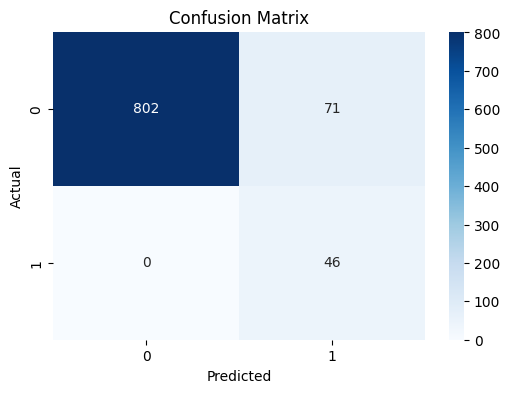

In [8]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))

print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('out/images/confusion_matrix.png')
plt.show()

## 10. Save Model
We save the model and the label encoders to use them in the WebApp.

In [9]:
model_data = {
    'model': best_model,
    'le_driver': le_driver,
    'le_constructor': le_constructor,
    'le_circuit': le_circuit,
    'feature_names': features
}

joblib.dump(model_data, 'out/models/f1_model_data.pkl')
print("Model saved to 'out/models/f1_model_data.pkl'")

Model saved to 'out/models/f1_model_data.pkl'


## 11. Deploy in WebApp
The WebApp code has been generated in `app.py`. 
To run the app, execute the following command in your terminal:

```bash
python app.py
```